In [1]:
!pip install fair-esm torch

In [2]:
import torch
print(torch.cuda.is_available())

False


In [3]:
%pip uninstall --force-reinstall --no-cache-dir numpy==1.26.4 pandas==2.0.3


Usage:   
  pip3 uninstall [options] <package> ...
  pip3 uninstall [options] -r <requirements file> ...

no such option: --force-reinstall


In [4]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, cohen_kappa_score, silhouette_score
)
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import esm
from sklearn.manifold import TSNE
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR

# Load ESM model
esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
batch_converter = alphabet.get_batch_converter()
esm_model.eval()

# Dataset Class with data augmentation
class PeptideDataset(Dataset):
    def __init__(self, csv_file, augment=False):
        df = pd.read_csv(csv_file)
        self.sequences = df['sequence'].astype(str).tolist()
        self.labels = df['FRS'].tolist()
        self.augment = augment

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        label = self.labels[idx]

        # Simple data augmentation - reverse sequence
        if self.augment and torch.rand(1).item() > 0.5:
            seq = seq[::-1]

        return seq, label

# ESM Embedding Extractor with caching
@torch.no_grad()
def extract_esm_embeddings(sequences):
    sequences_upper = [seq.upper() for seq in sequences]
    data = [("seq", seq) for seq in sequences_upper]
    batch_labels, batch_strs, batch_tokens = batch_converter(data)
    results = esm_model(batch_tokens, repr_layers=[6], return_contacts=False)
    token_representations = results["representations"][6]

    embeddings = []
    for i, seq in enumerate(sequences_upper):
        emb = token_representations[i, 1:len(seq)+1].mean(0)
        embeddings.append(emb)
    return torch.stack(embeddings)

# Improved TCN Blocks
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size,
                              stride=stride, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.bn1 = nn.BatchNorm1d(n_outputs)
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                              stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.bn2 = nn.BatchNorm1d(n_outputs)
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(
            self.conv1, self.chomp1, self.bn1, nn.GELU(), self.dropout1,
            self.conv2, self.chomp2, self.bn2, nn.GELU(), self.dropout2
        )
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.init_weights()

    def init_weights(self):
        nn.init.kaiming_normal_(self.conv1.weight, mode='fan_in')  # removed nonlinearity
        nn.init.kaiming_normal_(self.conv2.weight, mode='fan_in')  # removed nonlinearity
        if self.downsample is not None:
            nn.init.kaiming_normal_(self.downsample.weight, mode='fan_in')  # removed nonlinearity

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return F.gelu(out + res)

class TCN(nn.Module):
    def __init__(self, input_size, num_channels, kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        for i in range(len(num_channels)):
            dilation_size = 2 ** i
            in_channels = input_size if i == 0 else num_channels[i - 1]
            out_channels = num_channels[i]
            layers.append(
                TemporalBlock(in_channels, out_channels, kernel_size, stride=1,
                            dilation=dilation_size, padding=(kernel_size - 1) * dilation_size,
                            dropout=dropout)
            )
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Improved Adaptive Feature Fusion
class AdaptiveFusion(nn.Module):
    def __init__(self, esm_dim, tcn_dim):
        super().__init__()
        self.fc_esm = nn.Sequential(
            nn.Linear(esm_dim, esm_dim),
            nn.LayerNorm(esm_dim),
            nn.GELU()
        )
        self.fc_tcn = nn.Sequential(
            nn.Linear(tcn_dim, esm_dim),
            nn.LayerNorm(esm_dim),
            nn.GELU()
        )
        self.gate = nn.Sequential(
            nn.Linear(esm_dim * 2, esm_dim),
            nn.Sigmoid()
        )

    def forward(self, esm_feat, tcn_feat):
        esm_proj = self.fc_esm(esm_feat)
        tcn_proj = self.fc_tcn(tcn_feat)

        combined = torch.cat([esm_proj, tcn_proj], dim=1)
        gate = self.gate(combined)

        return gate * esm_proj + (1 - gate) * tcn_proj

# Label Smoothing Cross Entropy
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, x, target):
        log_probs = F.log_softmax(x, dim=-1)
        nll_loss = -log_probs.gather(dim=-1, index=target.unsqueeze(1))
        nll_loss = nll_loss.squeeze(1)
        smooth_loss = -log_probs.mean(dim=-1)
        loss = (1.0 - self.smoothing) * nll_loss + self.smoothing * smooth_loss
        return loss.mean()

# Improved LSTM with LayerNorm and dropout
class LayerNormLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, dropout=0.2):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)

        # Layer normalization
        self.ln_i = nn.LayerNorm(hidden_size)
        self.ln_h = nn.LayerNorm(hidden_size)
        self.ln_c = nn.LayerNorm(hidden_size)

    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward propagate LSTM
        out, (hn, cn) = self.lstm(x, (h0, c0))

        # Apply layer normalization
        hn = self.ln_h(hn)
        cn = self.ln_c(cn)

        return out, (hn, cn)

# Complete Classifier Model with improvements
class MultimodalClassifier(nn.Module):
    def __init__(self, esm_dim=320, tcn_input=21, tcn_channels=[64, 128], lstm_hidden=128, num_classes=2):
        super().__init__()

        # TCN pathway
        self.tcn = TCN(tcn_input, tcn_channels)

        # Feature fusion
        self.fusion = AdaptiveFusion(esm_dim, tcn_channels[-1])

        # LSTM pathway with layer normalization
        self.lstm = LayerNormLSTM(input_size=esm_dim, hidden_size=lstm_hidden,
                                num_layers=3, dropout=0.3)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden, lstm_hidden // 2),
            nn.LayerNorm(lstm_hidden // 2),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(lstm_hidden // 2, num_classes)
        )

        # Initialize weights
        self.init_weights()

    def init_weights(self):
        for name, param in self.named_parameters():
            if 'weight' in name:
                if param.dim() < 2:  # Skip initialization for 1D tensors
                    continue
                if 'lstm' in name.lower():
                    nn.init.orthogonal_(param)
                else:
                    nn.init.kaiming_normal_(param, mode='fan_in')
            elif 'bias' in name:
                nn.init.constant_(param, 0)

    def forward(self, esm_feats, onehot_seqs):
        # TCN pathway
        tcn_out = self.tcn(onehot_seqs.permute(0, 2, 1))
        tcn_summary = torch.mean(tcn_out, dim=2)  # Global pooling

        # Feature fusion
        fused = self.fusion(esm_feats, tcn_summary)

        # Prepare LSTM input (repeat fused features to simulate sequence)
        lstm_input = fused.unsqueeze(1).repeat(1, 10, 1)

        # LSTM pathway
        lstm_out, _ = self.lstm(lstm_input)

        # Classifier
        out = self.classifier(lstm_out[:, -1])
        return out

# Improved training function with gradient clipping, warmup, and more
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50,
               patience=5, grad_clip=1.0, grad_accum_steps=4):
    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float('inf')
    epochs_no_improve = 0

    # Learning rate schedulers
    warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lambda epoch: min(1.0, (epoch + 1) / 10))
    reduce_lr = ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        optimizer.zero_grad()

        for i, (sequences, labels) in enumerate(tqdm(train_loader)):
            esm_feats = extract_esm_embeddings(sequences)
            onehot_seqs = sequence_to_onehot(sequences).float()
            labels = torch.tensor(labels).long()

            outputs = model(esm_feats, onehot_seqs)
            loss = criterion(outputs, labels) / grad_accum_steps
            loss.backward()

            train_loss += loss.item() * grad_accum_steps

            # Gradient accumulation
            if (i + 1) % grad_accum_steps == 0 or (i + 1) == len(train_loader):
                # Gradient clipping
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
                optimizer.zero_grad()

        train_loss /= len(train_loader)
        history["train_loss"].append(train_loss)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for sequences, labels in val_loader:
                esm_feats = extract_esm_embeddings(sequences)
                onehot_seqs = sequence_to_onehot(sequences).float()
                labels = torch.tensor(labels).long()

                outputs = model(esm_feats, onehot_seqs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        history["val_loss"].append(val_loss)

        # Learning rate scheduling
        if epoch < 10:  # Warmup phase
            warmup_scheduler.step()
        else:
            reduce_lr.step(val_loss)

        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {optimizer.param_groups[0]['lr']:.2e}")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                print(f'Early stopping at epoch {epoch+1}')
                model.load_state_dict(torch.load('best_model.pt'))
                break

    return history

# Utility Functions
def sequence_to_onehot(sequences, max_len=100):
    amino_acids = 'RHKDESTNQCUGPAVILMFYW'
    aa_to_idx = {aa: i for i, aa in enumerate(amino_acids)}
    onehot = torch.zeros(len(sequences), max_len, len(amino_acids))
    for i, seq in enumerate(sequences):
        seq_upper = seq.upper()
        for j, aa in enumerate(seq_upper[:max_len]):
            if aa in aa_to_idx:
                onehot[i, j, aa_to_idx[aa]] = 1.0
    return onehot

def evaluate_model(model, data_loader):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for sequences, labels in data_loader:
            esm_feats = extract_esm_embeddings(sequences)
            onehot_seqs = sequence_to_onehot(sequences).float()
            outputs = model(esm_feats, onehot_seqs)
            preds = torch.argmax(outputs, dim=1).numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

    metrics = {
        "Accuracy": accuracy_score(all_labels, all_preds),
        "Precision": precision_score(all_labels, all_preds),
        "Recall": recall_score(all_labels, all_preds),
        "F1-score": f1_score(all_labels, all_preds),
        "MCC": matthews_corrcoef(all_labels, all_preds),
        "Cohen's Kappa": cohen_kappa_score(all_labels, all_preds)
    }

    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")

    return metrics

def plot_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training/Validation Loss")
    plt.show()

  0%|                                                  | 0/2000 [00:00<?, ?it/s]/home/molecular12/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_7189/4245870329.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels).long()
100%|███████████████████████████████████████| 2000/2000 [01:29<00:00, 22.39it/s]
/tmp/ipykernel_7189/4245870329.py:294: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(labels).long()


Epoch 1, Train Loss: 0.5275, Val Loss: 0.4335, LR: 2.00e-05


100%|███████████████████████████████████████| 2000/2000 [01:26<00:00, 23.01it/s]


Epoch 2, Train Loss: 0.4462, Val Loss: 0.4068, LR: 3.00e-05


100%|███████████████████████████████████████| 2000/2000 [01:27<00:00, 22.96it/s]


...

Epoch 46, Train Loss: 0.2031, Val Loss: 0.2030, LR: 3.13e-06


100%|███████████████████████████████████████| 2000/2000 [01:27<00:00, 22.74it/s]


Epoch 47, Train Loss: 0.2038, Val Loss: 0.2026, LR: 1.56e-06


100%|███████████████████████████████████████| 2000/2000 [01:27<00:00, 22.85it/s]


Epoch 48, Train Loss: 0.2031, Val Loss: 0.2016, LR: 1.56e-06
Early stopping at epoch 48


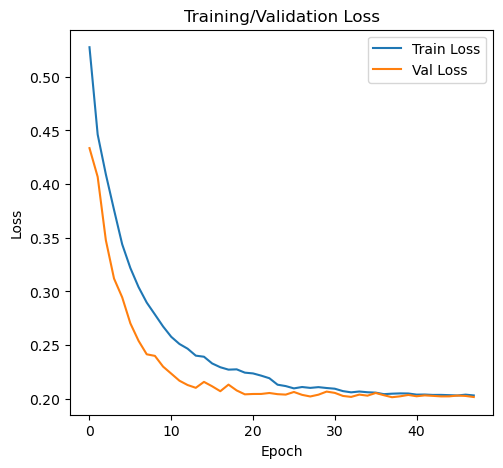


Train Set Evaluation:
Accuracy: 0.9999
Precision: 0.9999
Recall: 0.9998
F1-score: 0.9999
MCC: 0.9998
Cohen's Kappa: 0.9998

Validation Set Evaluation:


/home/molecular12/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.9982
Precision: 0.9992
Recall: 0.9971
F1-score: 0.9982
MCC: 0.9964
Cohen's Kappa: 0.9964


/home/molecular12/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


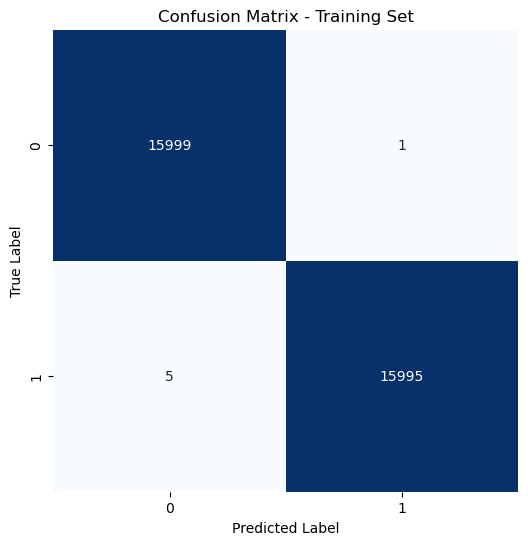

/home/molecular12/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


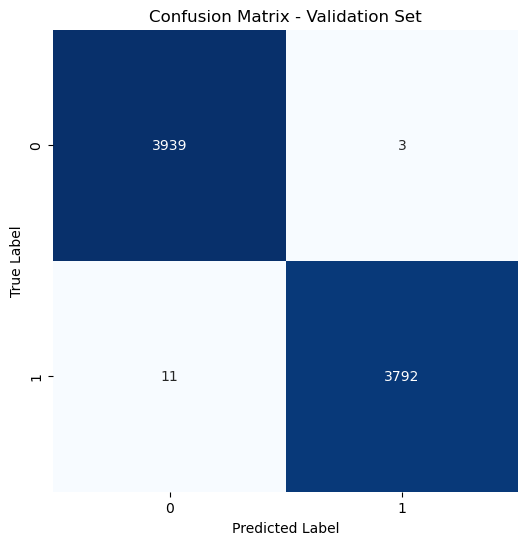

In [ ]:
if __name__ == "__main__":
    dataset_train = PeptideDataset("train_filtered.csv", augment=True)
    dataset_val = PeptideDataset("val_filtered.csv", augment=True)

    train_loader = DataLoader(dataset_train, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(dataset_val, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)

    model = MultimodalClassifier()

    # Use label smoothing and gradient clipping
    criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    history = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=100, patience=10, grad_clip=1.0, grad_accum_steps=2
    )

    plot_history(history)

    print("\nTrain Set Evaluation:")
    train_metrics = evaluate_model(model, train_loader)

    print("\nValidation Set Evaluation:")
    val_metrics = evaluate_model(model, val_loader)

    # Confusion matrix plotting
    from sklearn.metrics import confusion_matrix
    import seaborn as sns

    def plot_confusion_matrix(model, data_loader, title):
        all_preds, all_labels = [], []
        with torch.no_grad():
            for sequences, labels in data_loader:
                esm_feats = extract_esm_embeddings(sequences)
                onehot_seqs = sequence_to_onehot(sequences).float()
                outputs = model(esm_feats, onehot_seqs)
                preds = torch.argmax(outputs, dim=1).numpy()
                all_preds.extend(preds)
                all_labels.extend(labels)

        cm = confusion_matrix(all_labels, all_preds)
        plt.figure(figsize=(6, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title(title)
        plt.show()

    plot_confusion_matrix(model, train_loader, "Confusion Matrix - Training Set")
    plot_confusion_matrix(model, val_loader, "Confusion Matrix - Validation Set")

/home/molecular12/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


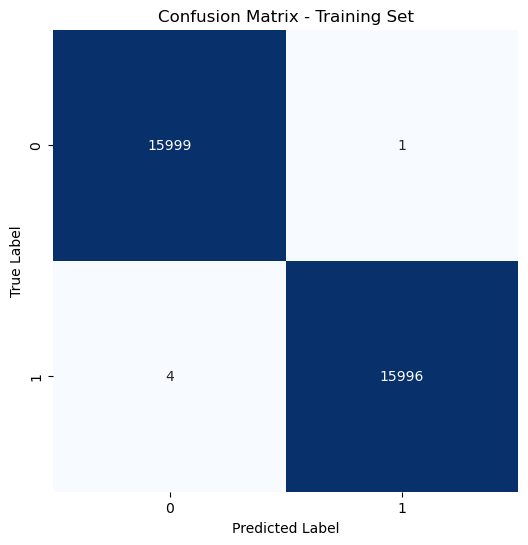

/home/molecular12/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


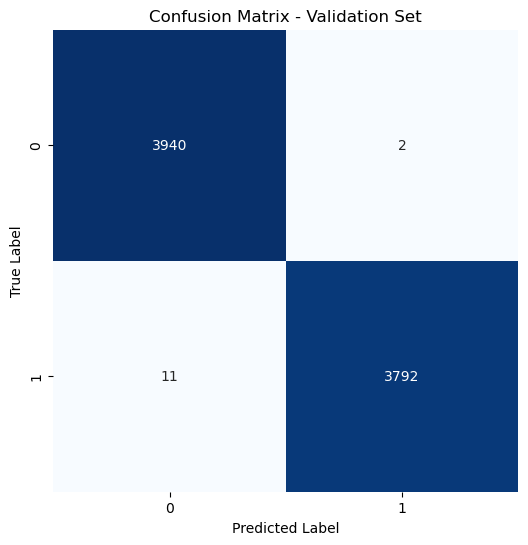

In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, data_loader, title):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for sequences, labels in data_loader:
            esm_feats = extract_esm_embeddings(sequences)
            onehot_seqs = sequence_to_onehot(sequences).float()
            outputs = model(esm_feats, onehot_seqs)
            preds = torch.argmax(outputs, dim=1).numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

plot_confusion_matrix(model, train_loader, "Confusion Matrix - Training Set")
plot_confusion_matrix(model, val_loader, "Confusion Matrix - Validation Set")


In [ ]:
import pandas as df
df = pd.read_csv("train_filtered.csv")
counts = df['FRS'].value_counts()
print(counts)

FRS
0    16000
1    16000
Name: count, dtype: int64


In [ ]:
import pandas as df
df = pd.read_csv("val_filtered.csv")
counts = df['FRS'].value_counts()
print(counts)

FRS
0    3942
1    3803
Name: count, dtype: int64


In [ ]:
# Save the trained model
torch.save(model.state_dict(), '01_AO_db_augmented_classifier.pth')

In [6]:
# To open the trained model, you would load the state dictionary back into a model instance
# First, instantiate a new model with the same architecture
model = MultimodalClassifier()

# Then, load the saved state dictionary
model.load_state_dict(torch.load('01_AO_db_augmented_classifier.pth'))

# Set the model to evaluation mode
model.eval()

print("Model loaded successfully!")

# You can now use loaded_model for inference on new data.
# Example (assuming you have new_sequences):
new_sequences = ["ARGLAKL", "AAVVRR"]
new_esm_feats = extract_esm_embeddings(new_sequences)
new_onehot_seqs = sequence_to_onehot(new_sequences).float()
with torch.no_grad():
     predictions = model(new_esm_feats, new_onehot_seqs)
     predicted_classes = torch.argmax(predictions, dim=1)
     print("Predictions:", predicted_classes)

Model loaded successfully!
Predictions: tensor([1, 1])


In [ ]:
# To open the trained model, you would load the state dictionary back into a model instance
# First, instantiate a new model with the same architecture
model = MultimodalClassifier()

# Then, load the saved state dictionary
model.load_state_dict(torch.load('01_AO_db_augmented_classifier.pth'))

# Set the model to evaluation mode
model.eval()

print("Model loaded successfully!")

# You can now use loaded_model for inference on new data.
# Example (assuming you have new_sequences):

import pandas as pd
# Load the original dataframe
#df = pd.read_csv('01_AO_db_test.csv')
#df

new_sequences = df["sequence"]
new_esm_feats = extract_esm_embeddings(new_sequences)
new_onehot_seqs = sequence_to_onehot(new_sequences).float()
with torch.no_grad():
     predictions = model(new_esm_feats, new_onehot_seqs)
     predicted_classes = torch.argmax(predictions, dim=1)
     print("Predictions:", predicted_classes)

Model loaded successfully!
Predictions: tensor([1, 0, 1,  ..., 1, 1, 0])


In [7]:
model.eval()
all_embeddings = []
all_labels = []

with torch.no_grad():
    for sequences, labels in DataLoader(dataset_train, batch_size=32):
        esm_feats = extract_esm_embeddings(sequences)
        onehot = sequence_to_onehot(sequences).float()

        tcn_out = model.tcn(onehot.permute(0,2,1))
        # Add global pooling to get a fixed-size representation from TCN output
        tcn_summary = torch.mean(tcn_out, dim=2) # Corrected line
        fused = model.fusion(esm_feats, tcn_summary) # Pass tcn_summary instead of tcn_out

        all_embeddings.append(fused.cpu().numpy())
        all_labels.extend(labels)

Z = np.vstack(all_embeddings)
labels = np.array(all_labels)

# Cosine similarity
sim_matrix = cosine_similarity(Z)

# Intra-class diversity
for cls in [0,1]:
    idx = np.where(labels == cls)[0]
    intra = sim_matrix[np.ix_(idx, idx)]
    diversity = 1 - np.mean(intra)
    print(f"Intra-class diversity (Class {cls}):", diversity)

# Inter-class similarity
idx0 = np.where(labels == 0)[0]
idx1 = np.where(labels == 1)[0]
inter = sim_matrix[np.ix_(idx0, idx1)]
print("Inter-class similarity:", np.mean(inter))

# Silhouette score
print("Silhouette Score:", silhouette_score(Z, labels))

# UMAP visualization
#reducer = umap.UMAP()
#Z_2d = reducer.fit_transform(Z)

#plt.figure(figsize=(6,5))
#sns.scatterplot(x=Z_2d[:,0], y=Z_2d[:,1], hue=labels)
#plt.title("Multimodal Embedding Space")
#plt.show()

Intra-class diversity (Class 0): 0.6394697
Intra-class diversity (Class 1): 0.5852791
Inter-class similarity: 0.28476024
Silhouette Score: 0.07701621


In [ ]:
def compute_diversity_metrics(Z, labels):
    """
    Computes:
    - Intra-class diversity
    - Inter-class similarity
    - Separation index
    - Silhouette score
    """
    sim_matrix = cosine_similarity(Z)
    labels = np.array(labels)

    idx0 = np.where(labels == 0)[0]
    idx1 = np.where(labels == 1)[0]

    intra0 = sim_matrix[np.ix_(idx0, idx0)]
    intra1 = sim_matrix[np.ix_(idx1, idx1)]
    inter = sim_matrix[np.ix_(idx0, idx1)]

    # Diversity = 1 - mean cosine similarity
    div0 = 1 - np.mean(intra0)
    div1 = 1 - np.mean(intra1)
    inter_sim = np.mean(inter)

    separation_index = (1 - inter_sim) / np.mean([div0, div1])
    silhouette = silhouette_score(Z, labels)

    metrics = {
        "Intra-class diversity (0)": div0,
        "Intra-class diversity (1)": div1,
        "Inter-class similarity": inter_sim,
        "Separation index": separation_index,
        "Silhouette score": silhouette
    }

    return metrics
metrics_dict = compute_diversity_metrics(Z, labels)
metrics_df = pd.DataFrame([metrics_dict])
metrics_df

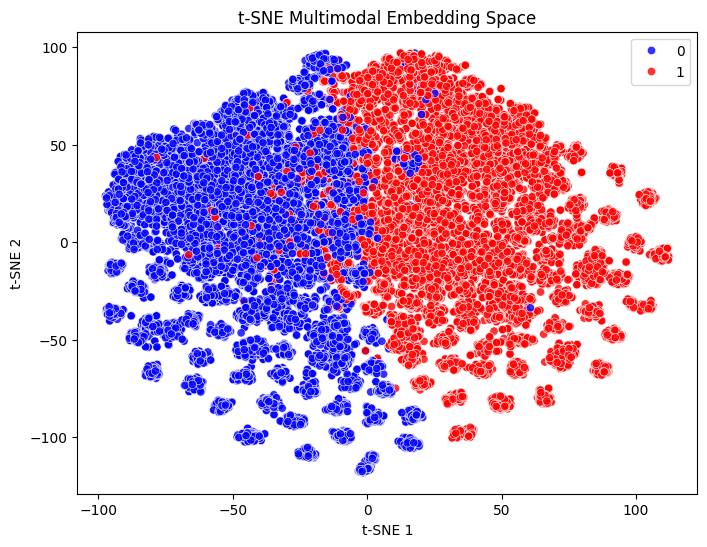

In [8]:
import seaborn as sns
from sklearn.manifold import TSNE
def plot_tsne(Z, labels, perplexity=30):
    """
    t-SNE projection of multimodal embeddings.
    """
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=42
    )

    Z_2d = tsne.fit_transform(Z)

    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x=Z_2d[:,0],
        y=Z_2d[:,1],
        hue=labels,
        palette=["blue", "red"],
        alpha=0.8
    )

    plt.title("t-SNE Multimodal Embedding Space")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.show()

    return Z_2d

Z_2d = plot_tsne(Z, labels, perplexity=30)

100%|███████████████████████████████████████| 1000/1000 [23:38<00:00,  1.42s/it]

Observed statistic (div1 - div0): -0.0416
Permutation p-value: 0.00000


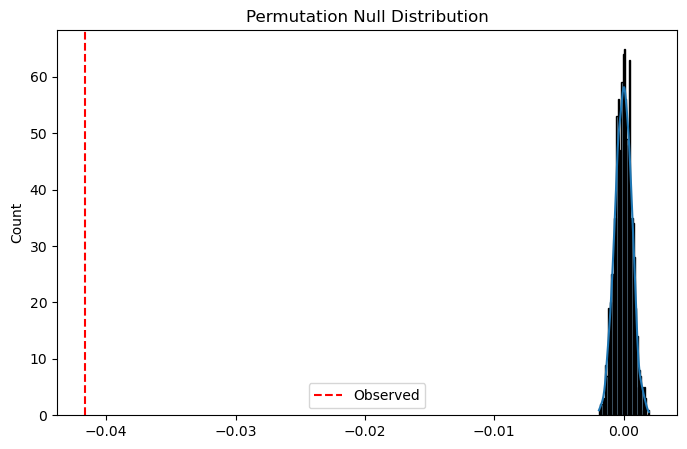

In [ ]:
def permutation_test_diversity(Z, labels, n_permutations=1000):
    """
    Permutation test for diversity difference between classes.
    """
    labels = np.array(labels)
    sim_matrix = cosine_similarity(Z)

    def compute_stat(lbls):
        idx0 = np.where(lbls == 0)[0]
        idx1 = np.where(lbls == 1)[0]

        intra0 = 1 - np.mean(sim_matrix[np.ix_(idx0, idx0)])
        intra1 = 1 - np.mean(sim_matrix[np.ix_(idx1, idx1)])

        return intra1 - intra0

    observed_stat = compute_stat(labels)
    perm_stats = []

    for _ in tqdm(range(n_permutations)):
        permuted_labels = np.random.permutation(labels)
        perm_stats.append(compute_stat(permuted_labels))

    perm_stats = np.array(perm_stats)

    p_value = np.mean(np.abs(perm_stats) >= np.abs(observed_stat))

    print(f"Observed statistic (div1 - div0): {observed_stat:.4f}")
    print(f"Permutation p-value: {p_value:.5f}")

    # Plot null distribution
    plt.figure(figsize=(8,5))
    sns.histplot(perm_stats, bins=40, kde=True)
    plt.axvline(observed_stat, color="red", linestyle="--", label="Observed")
    plt.title("Permutation Null Distribution")
    plt.legend()
    plt.show()

    return observed_stat, p_value

observed_stat, p_value = permutation_test_diversity(Z, labels, n_permutations=1000)

In [ ]:
def bootstrap_diversity_ci(Z, labels, n_bootstrap=1000):
    """
    Bootstrap confidence intervals for intra-class diversity.
    """
    labels = np.array(labels)
    sim_matrix = cosine_similarity(Z)

    idx0 = np.where(labels == 0)[0]
    idx1 = np.where(labels == 1)[0]

    boot_div0 = []
    boot_div1 = []

    for _ in tqdm(range(n_bootstrap)):
        sample0 = np.random.choice(idx0, size=len(idx0), replace=True)
        sample1 = np.random.choice(idx1, size=len(idx1), replace=True)

        div0 = 1 - np.mean(sim_matrix[np.ix_(sample0, sample0)])
        div1 = 1 - np.mean(sim_matrix[np.ix_(sample1, sample1)])

        boot_div0.append(div0)
        boot_div1.append(div1)

    ci0 = np.percentile(boot_div0, [2.5, 97.5])
    ci1 = np.percentile(boot_div1, [2.5, 97.5])

    print(f"Class 0 Diversity 95% CI: {ci0}")
    print(f"Class 1 Diversity 95% CI: {ci1}")

    return ci0, ci1

ci0, ci1 = bootstrap_diversity_ci(Z, labels, n_bootstrap=1000)

100%|███████████████████████████████████████| 1000/1000 [31:14<00:00,  1.87s/it]

Class 0 Diversity 95% CI: [0.63793855 0.64021537]
Class 1 Diversity 95% CI: [0.59609303 0.59888794]


In [9]:
model.eval()
all_embeddings = []
all_labels = []

with torch.no_grad():
    for sequences, labels in DataLoader(dataset_val, batch_size=32):
        esm_feats = extract_esm_embeddings(sequences)
        onehot = sequence_to_onehot(sequences).float()

        tcn_out = model.tcn(onehot.permute(0,2,1))
        # Add global pooling to get a fixed-size representation from TCN output
        tcn_summary = torch.mean(tcn_out, dim=2) # Corrected line
        fused = model.fusion(esm_feats, tcn_summary) # Pass tcn_summary instead of tcn_out

        all_embeddings.append(fused.cpu().numpy())
        all_labels.extend(labels)

Z = np.vstack(all_embeddings)
labels = np.array(all_labels)

# Cosine similarity
sim_matrix = cosine_similarity(Z)

# Intra-class diversity
for cls in [0,1]:
    idx = np.where(labels == cls)[0]
    intra = sim_matrix[np.ix_(idx, idx)]
    diversity = 1 - np.mean(intra)
    print(f"Intra-class diversity (Class {cls}):", diversity)

# Inter-class similarity
idx0 = np.where(labels == 0)[0]
idx1 = np.where(labels == 1)[0]
inter = sim_matrix[np.ix_(idx0, idx1)]
print("Inter-class similarity:", np.mean(inter))

# Silhouette score
print("Silhouette Score:", silhouette_score(Z, labels))

# UMAP visualization
#reducer = umap.UMAP()
#Z_2d = reducer.fit_transform(Z)

#plt.figure(figsize=(6,5))
#sns.scatterplot(x=Z_2d[:,0], y=Z_2d[:,1], hue=labels)
#plt.title("Multimodal Embedding Space")
#plt.show()

Intra-class diversity (Class 0): 0.63669604
Intra-class diversity (Class 1): 0.5822928
Inter-class similarity: 0.28503177
Silhouette Score: 0.07885047


In [ ]:
def compute_diversity_metrics(Z, labels):
    """
    Computes:
    - Intra-class diversity
    - Inter-class similarity
    - Separation index
    - Silhouette score
    """
    sim_matrix = cosine_similarity(Z)
    labels = np.array(labels)

    idx0 = np.where(labels == 0)[0]
    idx1 = np.where(labels == 1)[0]

    intra0 = sim_matrix[np.ix_(idx0, idx0)]
    intra1 = sim_matrix[np.ix_(idx1, idx1)]
    inter = sim_matrix[np.ix_(idx0, idx1)]

    # Diversity = 1 - mean cosine similarity
    div0 = 1 - np.mean(intra0)
    div1 = 1 - np.mean(intra1)
    inter_sim = np.mean(inter)

    separation_index = (1 - inter_sim) / np.mean([div0, div1])
    silhouette = silhouette_score(Z, labels)

    metrics = {
        "Intra-class diversity (0)": div0,
        "Intra-class diversity (1)": div1,
        "Inter-class similarity": inter_sim,
        "Separation index": separation_index,
        "Silhouette score": silhouette
    }

    return metrics
metrics_dict = compute_diversity_metrics(Z, labels)
metrics_df = pd.DataFrame([metrics_dict])
metrics_df

,Intra-class diversity (0),Intra-class diversity (1),Inter-class similarity,Separation index,Silhouette score
0,0.63928,0.597859,0.257279,1.200707,0.089468


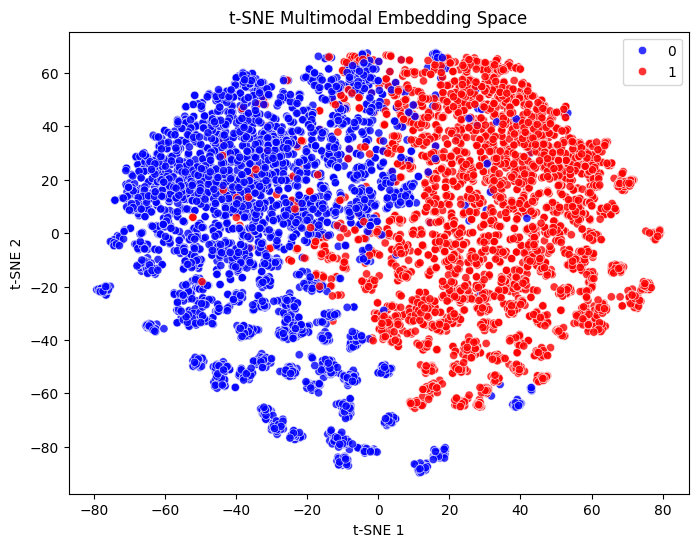

In [10]:
def plot_tsne(Z, labels, perplexity=30):
    """
    t-SNE projection of multimodal embeddings.
    """
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="pca",
        random_state=42
    )

    Z_2d = tsne.fit_transform(Z)

    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x=Z_2d[:,0],
        y=Z_2d[:,1],
        hue=labels,
        palette=["blue", "red"],
        alpha=0.8
    )

    plt.title("t-SNE Multimodal Embedding Space")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.show()

    return Z_2d

Z_2d = plot_tsne(Z, labels, perplexity=30)

100%|███████████████████████████████████████| 1000/1000 [22:55<00:00,  1.38s/it]

Observed statistic (div1 - div0): -0.0414
Permutation p-value: 0.00000


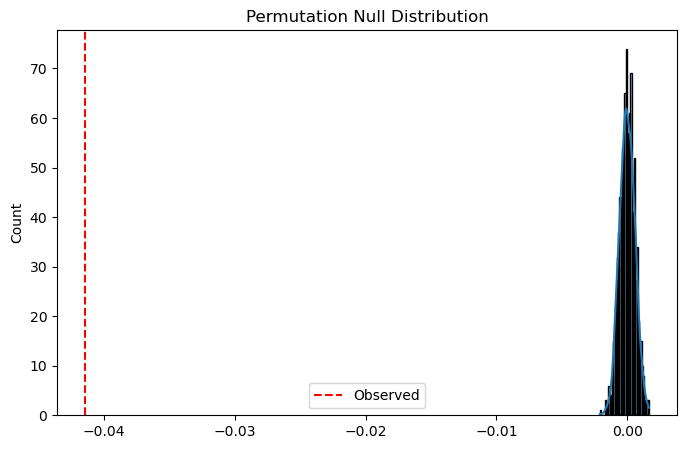

In [ ]:
def permutation_test_diversity(Z, labels, n_permutations=1000):
    """
    Permutation test for diversity difference between classes.
    """
    labels = np.array(labels)
    sim_matrix = cosine_similarity(Z)

    def compute_stat(lbls):
        idx0 = np.where(lbls == 0)[0]
        idx1 = np.where(lbls == 1)[0]

        intra0 = 1 - np.mean(sim_matrix[np.ix_(idx0, idx0)])
        intra1 = 1 - np.mean(sim_matrix[np.ix_(idx1, idx1)])

        return intra1 - intra0

    observed_stat = compute_stat(labels)
    perm_stats = []

    for _ in tqdm(range(n_permutations)):
        permuted_labels = np.random.permutation(labels)
        perm_stats.append(compute_stat(permuted_labels))

    perm_stats = np.array(perm_stats)

    p_value = np.mean(np.abs(perm_stats) >= np.abs(observed_stat))

    print(f"Observed statistic (div1 - div0): {observed_stat:.4f}")
    print(f"Permutation p-value: {p_value:.5f}")

    # Plot null distribution
    plt.figure(figsize=(8,5))
    sns.histplot(perm_stats, bins=40, kde=True)
    plt.axvline(observed_stat, color="red", linestyle="--", label="Observed")
    plt.title("Permutation Null Distribution")
    plt.legend()
    plt.show()

    return observed_stat, p_value

observed_stat, p_value = permutation_test_diversity(Z, labels, n_permutations=1000)

In [ ]:
def bootstrap_diversity_ci(Z, labels, n_bootstrap=1000):
    """
    Bootstrap confidence intervals for intra-class diversity.
    """
    labels = np.array(labels)
    sim_matrix = cosine_similarity(Z)

    idx0 = np.where(labels == 0)[0]
    idx1 = np.where(labels == 1)[0]

    boot_div0 = []
    boot_div1 = []

    for _ in tqdm(range(n_bootstrap)):
        sample0 = np.random.choice(idx0, size=len(idx0), replace=True)
        sample1 = np.random.choice(idx1, size=len(idx1), replace=True)

        div0 = 1 - np.mean(sim_matrix[np.ix_(sample0, sample0)])
        div1 = 1 - np.mean(sim_matrix[np.ix_(sample1, sample1)])

        boot_div0.append(div0)
        boot_div1.append(div1)

    ci0 = np.percentile(boot_div0, [2.5, 97.5])
    ci1 = np.percentile(boot_div1, [2.5, 97.5])

    print(f"Class 0 Diversity 95% CI: {ci0}")
    print(f"Class 1 Diversity 95% CI: {ci1}")

    return ci0, ci1

ci0, ci1 = bootstrap_diversity_ci(Z, labels, n_bootstrap=1000)

100%|███████████████████████████████████████| 1000/1000 [30:51<00:00,  1.85s/it]

Class 0 Diversity 95% CI: [0.6381126 0.640458 ]
Class 1 Diversity 95% CI: [0.59639031 0.59929773]


In [ ]:
!pip install logomaker

Defaulting to user installation because normal site-packages is not writeable


Total extracted motifs: 80000

Cluster 0:
['YLGAKHL', 'LGAKHLH', 'IIENGEK', 'TIIENGE', 'PSYPELF', 'AYPSYPE', 'YSLGIIS', 'WYSLGII', 'IKNYRVA', 'KNYRVAV']

Cluster 4:
['LPDEVSG', 'EVSGPEV', 'VNVDDPS', 'NVDDPSK', 'WDDMEKY', 'LNGLEGL', 'GLNGLEG', 'SELGYLD', 'LTDMEPK', 'PVQALLD']

Cluster 2:
['ALPLAPQ', 'KALPLAP', 'SLDFPAL', 'LDFPALW', 'LPGKPKP', 'PGKPKPD', 'PKLAPNE', 'NLNANIV', 'WNLNANI', 'TDADTMK']

Cluster 1:
['DSGVTCM', 'SGVTCME', 'ALTMFPS', 'LTMFPSA', 'YQGPFCD', 'GPFCDIF', 'YPQRRWH', 'PYPQRRW', 'KLPWRPA', 'EKLPWRP']

Cluster 3:
['QEHSGEH', 'QQEHSGE', 'FLHRPPP', 'LHRPPPQ', 'HPHPHLS', 'DRFQDQH', 'HHGPVRG', 'PHHGPVR', 'HDHQNSI', 'EHSGEHQ']


<Figure size 800x300 with 0 Axes>

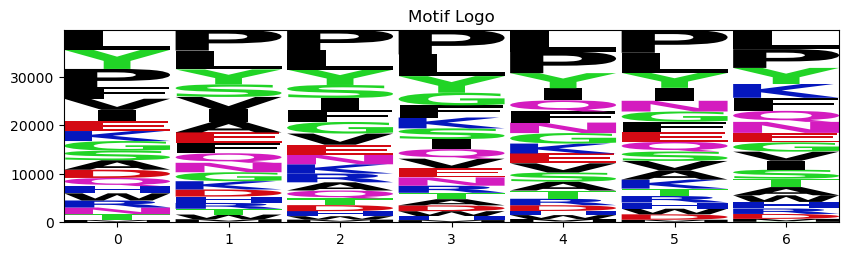

In [ ]:
def compute_saliency(model, sequences, target_class=1):
    model.eval()
    saliency_scores = []

    for seq in sequences:
        onehot = sequence_to_onehot([seq]).float()
        esm_feat = extract_esm_embeddings([seq])

        onehot.requires_grad = True

        output = model(esm_feat, onehot)
        score = output[0, target_class]

        model.zero_grad()
        score.backward()

        saliency = onehot.grad.abs().sum(dim=2).squeeze().cpu().detach().numpy()
        saliency_scores.append(saliency[:len(seq)])

    return saliency_scores

def extract_motifs(sequences, saliency_scores, window=7, top_k=3):
    motifs = []

    for seq, sal in zip(sequences, saliency_scores):
        if len(seq) < window:
            continue

        scores = []
        for i in range(len(seq)-window+1):
            scores.append(np.mean(sal[i:i+window]))

        top_indices = np.argsort(scores)[-top_k:]

        for idx in top_indices:
            motif = seq[idx:idx+window]
            motifs.append(motif)

    print("Total extracted motifs:", len(motifs))
    return motifs

from sklearn.cluster import AgglomerativeClustering

def cluster_motifs(motifs, n_clusters=5):
    motif_embeddings = extract_esm_embeddings(motifs).cpu().numpy()

    clustering = AgglomerativeClustering(n_clusters=n_clusters)
    labels = clustering.fit_predict(motif_embeddings)

    clustered = {}
    for motif, lbl in zip(motifs, labels):
        clustered.setdefault(lbl, []).append(motif)

    for cluster_id, cluster_motifs in clustered.items():
        print(f"\nCluster {cluster_id}:")
        print(cluster_motifs[:10])

    return clustered

import logomaker
import pandas as pd

def plot_motif_logo(motif_list):
    if len(motif_list) == 0:
        return

    length = len(motif_list[0])
    counts = pd.DataFrame(0, index=range(length), columns=list("ACDEFGHIKLMNPQRSTVWY"))

    for motif in motif_list:
        for i, aa in enumerate(motif):
            if aa in counts.columns:
                counts.loc[i, aa] += 1

    plt.figure(figsize=(8,3))
    logomaker.Logo(counts)
    plt.title("Motif Logo")
    plt.show()

# ---- SALIENCY + MOTIF ANALYSIS ----
all_sequences = full_dataset.sequences
saliency_scores = compute_saliency(model, all_sequences, target_class=1)

motifs = extract_motifs(all_sequences, saliency_scores, window=7, top_k=2)
clustered_motifs = cluster_motifs(motifs, n_clusters=5)

# Plot logo for first cluster
plot_motif_logo(clustered_motifs[0])